 # Analisi delle comunità della rete Immigrazione 2023
 In questo capitolo, procederemo con l'analisi delle comunità A e B della rete. In particolare confronteremo le metriche di centralità, defininendo le proprietà topologiche dei due gruppi.

 ## Studio delle distibuzioni di centralita per A e B
 Abbiamo calcolato la distibuzione delle misure di centralità della rete, evidenziando le differenze tra le due comunità.
 Le misure (ad eccezione della coreness) sono state normalizzate, come di seguito.
Le misure calcolate sono le seguenti e ci permettono di rispondere alle relative domande:
- L'**eigenvector centrality** misura l'importanza del nodo in relazione all'importanza dei nodi a cui è connesso; è definita dalla formula ricorsiva:
$$ x_{i} = {1 \over \lambda} \sum_{j}A_{ij} x_j $$
normalizzata come $ x_i^{norm} = {x_i \over \max_j(x_j)} $,
 - La **coreness** calcola la scomposizione in $k_{\text{core}}$, dove il $k_{\text{core}}$ è il sottografo massimale in cui tutti i nodi hanno grado interno maggiore o uguale a $k$.
 $$ \text{coreness}(v) = \max\{k | v \in k_{\text{core}}\} $$

dove $x_i$ è la centralità del nodo $i$ e $A_{ij}$ è la matrice di adiacenza del grafo. 

*Qual è la struttura gerarchica della rete? E' simmetrica nelle due comunità? E' possibile identificare un core di nodi più densamente connessi?*

 - La **closeness centrality** misura quanto un nodo sia "vicino" agli altri nodi del grafo:
 $$ \text{closeness}(v) = {(N-1)\over \sum_{u\neq v}d(u,v)}$$
 dove $N$ è il numero di nodi e $d(u,v)$ è lo shortest path tra i nodi $u$ e $v$.
 - La **betweenness centrality** misura quante volte un nodo si trova sul cammino minimo tra tutte le possibili coppie di altri nodi:
 $$\text{betweenness}(v) = {2 \over (N-1)(N-2)}\sum_{u\neq v, k \neq v}{\sigma_{uk}(v) \over \sigma_{uk}}$$
 dove $\sigma_{uk}$ è il numero di shortest paths tra il nodo $u$ e $k$, mentre $\sigma_{uk}(v)$ è il numero di shortest paths che passano per il nodo $v$. La normalizzazione tiene conto di tutte le possibili coppie non ordinate $(u, v)$. Ci permette di studiare come sono dsitribuiti i nodi fondamentali per la connessione dell'intera rete.

*Come si presenta la struttura geometrica della rete? Ci sono nodi fondamentali per il flusso di informazione all'interno della rete e tra le due comunità?*

In [4]:
from utils import *
from visualization_utils import *
import matplotlib.pyplot as plt
import numpy as np
import igraph as ig
import pandas as pd

In [5]:
graph_path = DATA_DIR + 'Centrality/Centrality_immigration_23.graphml'
G = load_graph(graph_path)

/home/lore/PyProjects/Networks/AVRC_FinnishTwittersphereProject/Code/utils.py:28: RuntimeWarning: Could not add vertex ids, there is already an 'id' vertex attribute. Location: src/io/graphml.c:434
  return ig.Graph.Read_GraphML(filename)


Abbiamo realizzato due istogrammi relativi ad A e B, per ogni centralità. 
Ogni istogramma misura il numero di nodi della comunità che presentano uno specifico valore della metrica calcolata sull'intera rete.

In [4]:
def plot_centralities(G: ig.Graph, savefile=''):
    ''' Calcola le misure di centralità sull'intera rete e poi realizza un istogramma con i conteggi divisi per comunità
    '''
    metrics = ['coreness', 'eigenvector', 'closeness', 'betweenness']
    fig, axes = plt.subplots(2, 2, figsize=(15,9))

    for ax, m in zip(axes.flat, metrics):
        values = np.array(G.vs[m], dtype=float)

        # Separa i due gruppi
        maskA = [group == 'A' for group in G.vs['group']]
        maskB = [group == 'B' for group in G.vs['group']]
        valuesA = np.array(values[maskA])
        valuesB = np.array(values[maskB])

        # Rimuovi eventuali zeri (per logaritmo)
        valuesA = valuesA[valuesA > 0]
        valuesB = valuesB[valuesB > 0]

        if m == 'coreness':
            # calcolo della mediana 
            medA_plot = np.median(valuesA)
            medB_plot = np.median(valuesB)
            # Coreness è intera: usiamo i valori direttamente come bin edges
            min_val = min(valuesA.min(), valuesB.min())
            max_val = max(valuesA.max(), valuesB.max())
            bins = np.arange(min_val, max_val + 2) - 0.5  # centri sugli interi
            # Calcola istogrammi 
            histA, edgesA = np.histogram(valuesA, bins=bins, density=False)
            histB, edgesB = np.histogram(valuesB, bins=bins, density=False)
            bin_centers = (bins[:-1] + bins[1:]) / 2
            bin_widths = np.diff(bins)
            ylabel = 'coreness'
            # Non trasformiamo l'asse y
        else:
            # Trasformazione logaritmica per le altre metriche
            logA = np.log10(valuesA)
            logB = np.log10(valuesB)
            # calcolo della mediana
            medA_plot = np.median(logA)
            medB_plot = np.median(logB)

            all_log = np.concatenate([logA, logB])
            bins = np.linspace(all_log.min(), all_log.max(), 40)
            histA, edgesA  = np.histogram(logA, bins=bins, density=False)
            histB, edgesB = np.histogram(logB, bins=bins, density=False)
            bin_centers = (bins[:-1] + bins[1:]) / 2
            bin_widths = np.diff(bins)
            ylabel = m
        
        # Istogrammi specchiati: A a sinistra (larghezza negativa), B a destra (positiva)
        ax.barh(bin_centers, width=-histA, height=bin_widths,
                color=color_group['A'], alpha=0.5, edgecolor='white', label='A')
        ax.barh(bin_centers, width=histB, height=bin_widths,
                color=color_group['B'], alpha=0.5, edgecolor='white', label='B')
    
        max_density = max(histA.max(), histB.max()) * 1.3
        ax.set_xlim(-max_density, max_density)

        # PLOT mediane
        ax.hlines(medA_plot, xmin=-max_density, xmax=0,
                  color=color_group['A'], linestyle='--', linewidth=1.5,
                  label=f'Mediana A')
        # B: linea da 0 verso destra (positivo)
        ax.hlines(medB_plot, xmin=0, xmax=max_density,
                  color=color_group['B'], linestyle='--', linewidth=1.5,
                  label=f'Mediana B')
        

        # Imposta l'asse x in modo simmetrico
        max_density = max(histA.max(), histB.max()) * 1.3
        ax.set_xlim(-max_density, max_density)
        
        ax.set_xlabel('Conteggi')
        ax.set_ylabel(ylabel)
        ax.grid(alpha=0.3, axis='x')   # solo griglie verticali
        

        # Personalizza le etichette dell'asse y per le metriche logaritmiche
        if m != 'coreness':
            # Mostra alcune etichette in scala originale
            yticks_log = np.linspace(bins.min(), bins.max(), 5)
            ax.set_yticks(yticks_log)
            ax.set_yticklabels([f'$10^{{{v:.1f}}}$' for v in yticks_log])
            hist_max = max(((histA.max()+99) // 100)*100, ((histB.max()+99)//100)*100)
            xticks = np.linspace(-hist_max, hist_max, 5)
            ax.set_xticks(xticks)
            ax.set_xticklabels(map(int,abs(xticks)))
        else:
            # Per coreness, mostra valori interi
            ax.set_yticks(np.arange(0, max_val+1, 5))
            ax.set_xscale('symlog')
            ticks_exp = [-1000, -100, -10, -1, 0, 1, 10, 100, 1000]
            ax.set_xticks(ticks_exp)
            ax.set_xticklabels(['$10^3$', '$10^2$', '10', '1', '0', '1', '10', '$10^2$', '$10^3$'])
            ax.legend(frameon=True, bbox_to_anchor=(0, 1.4), loc='upper left')

        ax.set_title(m.capitalize(), fontsize=FONTSIZE_TITLE)    
        ax.tick_params(direction='out')

    
    fig.suptitle("Distribuzione misure di centralità per le due comunità", fontsize=FONTSIZE_SUPTITLE, y=1.02)
    plt.tight_layout()
    if savefile:
        plt.savefig(savefile)
    else:
        plt.show()
    plt.close(fig)


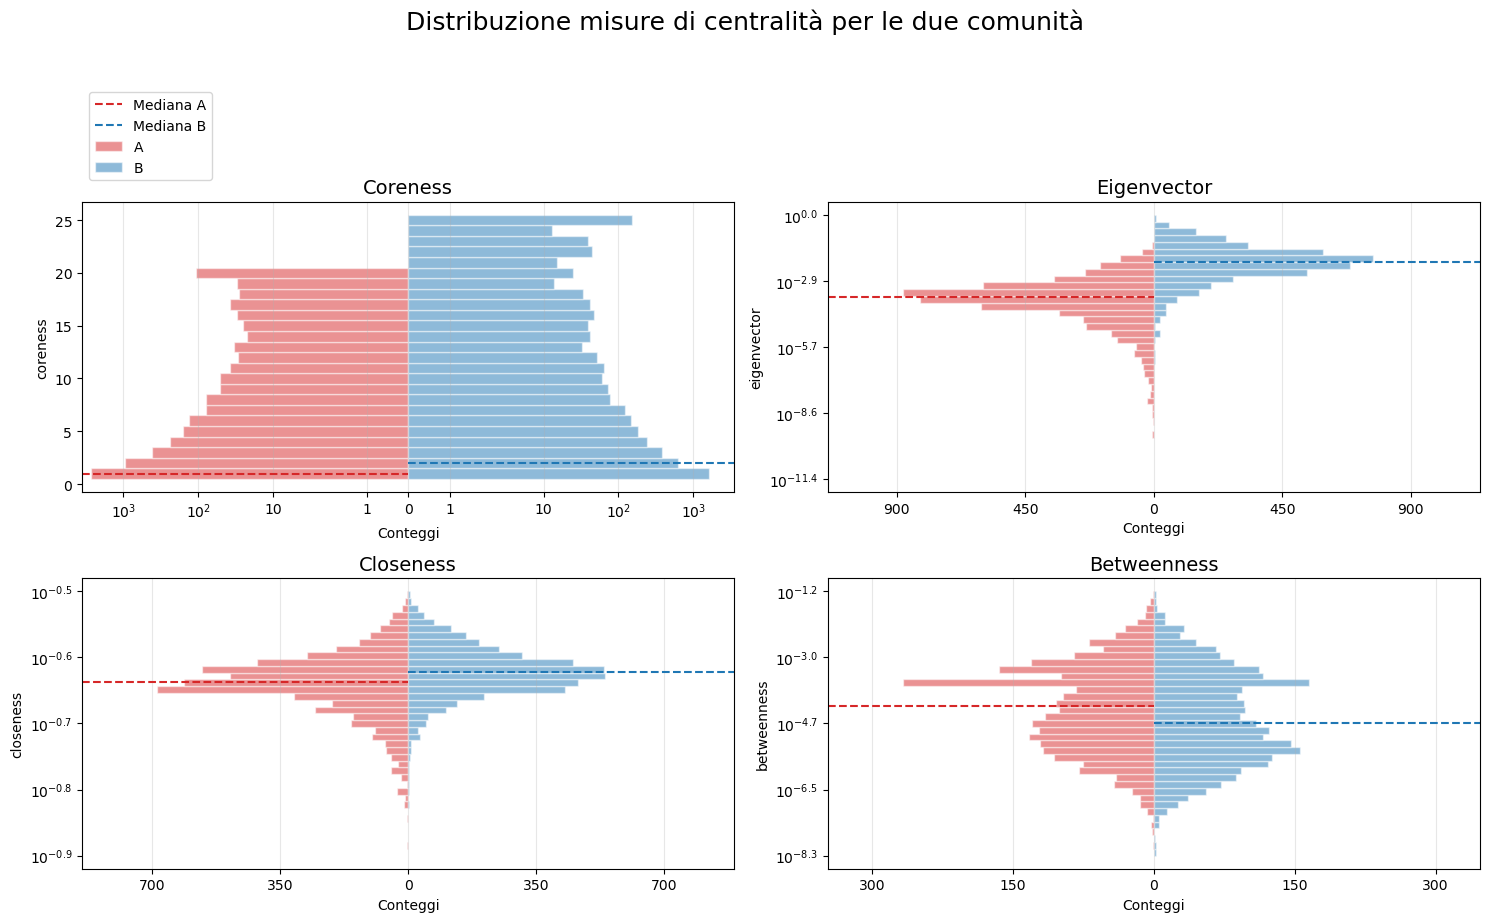

In [35]:
plot_centralities(G)

Dal grafico estrapoliamo le seguenti informazioni sulla rete.
- **Coreness**: Per entrambe le comunità dominano fortemente i core più piccoli, ovvero la grande maggioranza dei nodi si concentra nei primi due k-core. Il gruppo B ha molti più nodi nei k-core più alti arrivando a formare un picco locale in k=25, a differenza di A in cui si limitano a k=20.
Si può dedurre che B abbia un core più denso e connesso, ovvero una struttura a camera d'eco in cui i nodi si rinforzano a vicenda. Mentre A presenta una struttura con più nodi periferici.

- **Eigenvector**: Notiamo come la mediana di B sia di due ordini di grandezza più alta della mediana di A. Questo siginifica che i nodi di B sono significativamente più vicini a nodi influenti, il che rinforza le considerazioni precedenti. 

- **Closeness**: La mediana di A e B sono confrontabili. A ha una coda più pesante verso valori più bassi di closeness e questo indica che la comunità è meno accentrata intorno al suo core, ovvero ci sono molti nodi periferici lontani dai nodi più importanti.

- **Betweenness**: In questo caso, A ha la mediana più alta. Questo può essere dovuto al fatto che A è ha una struttura meno connessa, quindi i nodi che ne connettono le parti hanno una betweenness maggiore. B invece ha una struttura ridondante nei cammini con più nodi a valori bassi.

Per comprendere come le centralità sono legate tra loro, riportiamo il grafico della matrice di Spearman.

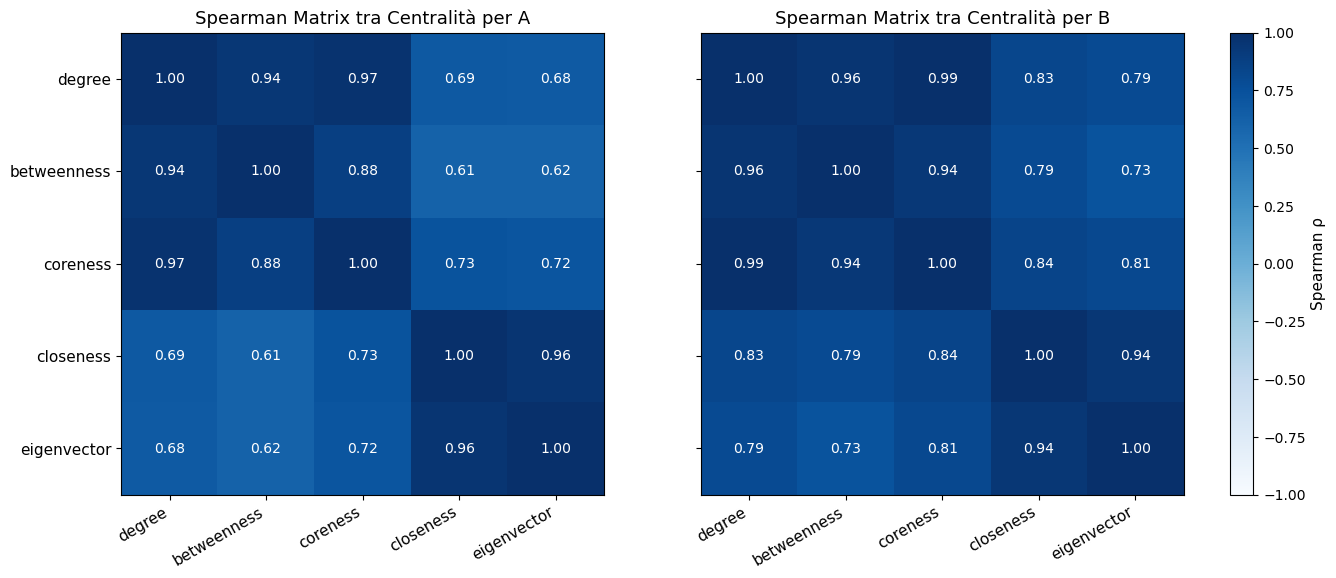

In [117]:
from scipy.stats import spearmanr
import matplotlib.colors as mcolors

def spearman(centralities: dict):
    '''Prende il dizionario con le centralità e restituisce la matrice di Spearmanr'''
    labels = list(centralities.keys())
    n = len(labels)
    data = np.array([centralities[k] for k in labels])  # shape (4, n_nodes)

    # Matrice di correlazione di Spearman 
    corr_matrix = np.ones((n, n))
    pval_matrix = np.ones((n, n))

    for i in range(n):
        for j in range(i + 1, n):
            r, p = spearmanr(data[i], data[j])
            corr_matrix[i, j] = r
            corr_matrix[j, i] = r
            pval_matrix[i, j] = p
            pval_matrix[j, i] = p
    return corr_matrix, labels   


fig, ax = plt.subplots(1, 2, figsize=FIGSIZE_LARGE, sharey=True)

for k, groups in enumerate(GROUP):
    # Separa i due gruppi
    mask = [group == groups for group in G.vs['group']]


    # Calcola le centralità in un dizionario
    centralities = {
        'degree':      np.array(G.vs['degree'])[mask],
        'betweenness': np.array(G.vs['betweenness'])[mask],
        'coreness':    np.array(G.vs['coreness'])[mask],
        'closeness':   np.array(G.vs['closeness'])[mask],
        'eigenvector': np.array(G.vs['eigenvector'])[mask]
    }



    corr_matrix, labels = spearman(centralities)
    n = len(labels)

    # Colormap divergente centrata su 0
    vmin, vmax = -1, 1
    norm = mcolors.TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)

    im = ax[k].imshow(corr_matrix, cmap=CMAP_HEAT, norm=norm, aspect='auto')
    # Colorbar
    if k==0:
        cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        cbar.set_label("Spearman ρ", fontsize=11)


    # Etichette assi
    ax[k].set_xticks(range(n))
    ax[k].set_yticks(range(n))
    ax[k].set_xticklabels(labels, rotation=30, ha='right', fontsize=11)
    ax[k].set_yticklabels(labels, fontsize=11)
    ax[k].set_title("Spearman Matrix tra Centralità per " + groups, fontsize=13)
    
    low = corr_matrix.min() if vmin is None else vmin
    high = corr_matrix.max() if vmax is None else vmax
    threshold = (low + high) / 2.0 if high > low else high
    for i in range(corr_matrix.shape[0]):
        for j in range(corr_matrix.shape[1]):
            value = corr_matrix[i, j]
            text_color = 'white' if value >= threshold else 'black'
            ax[k].text(
                j,
                i,
                f"{value:.2f}",
                ha='center',
                va='center',
                color=text_color,
            )
        
plt.show()

plt.close(fig)        

Notiamo come in B ci siano delle correlazioni maggiori rispetto ad A in quasi tutte le metriche, in particolare:
- **Closeness - Degree**: in B la correlazione è alta (0.83), quindi nodi strutturamente vicini agli altri sono quelli con alto grado. In A questo legame è meno forte (0.69): possiamo dedurre che tale fenomeno sia dovuto alla presenta di moltissimi nodi periferici in A con grado basso. Questo individua in A una struttura più periferica. 
- **Degree - Eigenvector**: analogamente, in B (0.79) nodi con alto degree sono connessi a nodi importanti, ovvero gli hub della rete sono connessi tra loro. In A (0.68) ci sono molti nodi con basso grado connessi a nodi periferici.
- **Betweenness - Coreness/Closeness**: in B chi è un ponte efficace è sia un nodo che fa parte del core denso che un nodo ben posizionato globalmente. In A puoi essere un bridge anche se sei strutturamente lontano dal core e quindi anche se fai parte della struttura più periferica.


In [ ]:
def plot_metric_vs_metric(G, metric_x, metric_y, metric_size=None):
    fig, axs = plt.subplots(1, 2, figsize=FIGSIZE_LARGE, sharex=True, sharey=True, layout='tight')
    for (ax, gr) in zip(axs, GROUP):
        mask = [group == gr for group in G.vs['group']]
        size_min, size_max = 12, 240

        x = np.array(G.vs[metric_x])
        y = np.array(G.vs[metric_y])
        if metric_size:
            z = np.array(G.vs[metric_size])[mask]
            s = np.interp(z, (z.min(), z.max()), (size_min, size_max))
        else:
            s = 10    
        ax.scatter(x[mask], y[mask], s=s, alpha=0.4, color=color_group[gr], label=gr)
        ax.set_title(f'{metric_y} vs {metric_x}', fontsize=FONTSIZE_TITLE)
        ax.set_xlabel(metric_x)
        ax.set_ylabel(metric_y)
        ax.legend()
        ax.set_xscale('log')
        ax.set_yscale('log')



A riprova di quanto detto a commento della Sperman Matrix, la periferia di A risulta molto diversa da quella di B. In A ci sono molti nodi periferici con grado basso connessi ad altri nodi periferici rispetto a B, dove la closeness è lineare nel grado. La periferia risulta più ampia per A.

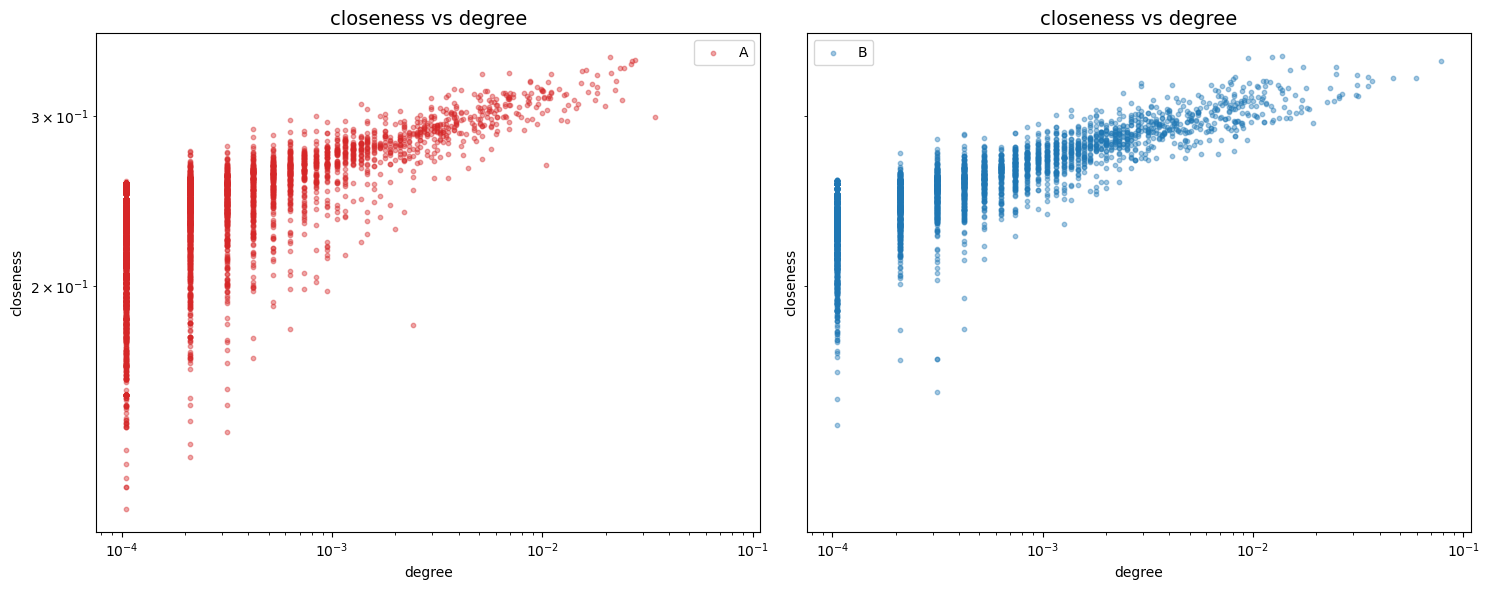

In [ ]:
plot_metric_vs_metric(G, 'degree', 'closeness')

# Misure di Assortatività di grado

Per testare l'ipotesi di una struttura core-periphery della rete, studiamo l'**assortatività di grado**. In particolare abbiamo calcolato per i sottografi relativi alle due comunità la *degree correlation function* $knn(k)$, che misura il grado medio dei nodi vicini ai nodi di grado $k$. Si calcola come:
$$ k_{nn}(k) = { \sum_{d_i=k}k_{i} \over n_k}$$
dove $k_i$ è la media del grado dei vicini del nodo $i$ e $n_k$ è il numero di nodi di grado $k$

In [35]:
nodi_A = G.vs.select(group="A")
G_A = G.subgraph(nodi_A)
nodi_B = G.vs.select(group="B")
G_B = G.subgraph(nodi_B)

In [57]:
from scipy.stats import linregress

def compute_knn(G):
    knn_node, knn_degree = G.knn()
    k = []
    knn = []

    for k_val, val in enumerate(knn_degree):
        # Consideriamo solo i gradi esistenti nella rete (valori non nulli/NaN)

        if val > 0 and k_val > 0 and not np.isnan(val):
            k.append(k_val)
            knn.append(val)
    return np.array(k), np.array(knn)

def plot_knn(G: ig.Graph | list[ig.Graph], legend=None):

    if isinstance(G, ig.Graph):
        G = [G]

    if legend is None:
        legend = [str(i) for i in range(1, len(G)+1)]    

    fig, ax = plt.subplots(figsize=FIGSIZE)

    
    for graph, color, label in zip(G, (color_group['A'], color_group['B']), legend):

        r = graph.assortativity_degree(directed=False) 
        k, knn = compute_knn(graph)
        slope, intercept, R, p, _ = linregress(np.log10(k), np.log10(knn))
        xline = np.linspace(k.min(), k.max(), 100)
        ax.plot(xline, 10**intercept * (xline**slope), linestyle='--', linewidth=1.6, color=lighten_color(color), label=f"slope={slope:.2f}")
        


        ax.scatter(k, knn, s=10, alpha=0.7,color=color, label=label)
        ax.set_xscale('log')
        ax.set_yscale('log')  
        ax.set_xlabel("grado k")
        ax.set_ylabel("knn(k)")  
        ax.text(0.1, 0.1, ("Assortativa" if slope > 0 else "Disassortativa"),
            transform=ax.transAxes, fontsize=FONTSIZE_TITLE, verticalalignment='bottom', horizontalalignment='left',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8, edgecolor='gray'))
        
        print(f"Grafo: {label}: r={r:.4f}, slope={slope:.4f}")
    
    fig.suptitle("Degree correlation function knn(k)", fontsize=FONTSIZE_SUPTITLE)
    
    ax.legend()
    plt.savefig('knn_plot.png')
    plt.show()
    


Grafo: A: r=-0.2202, slope=-0.2773
Grafo: B: r=-0.2432, slope=-0.4218


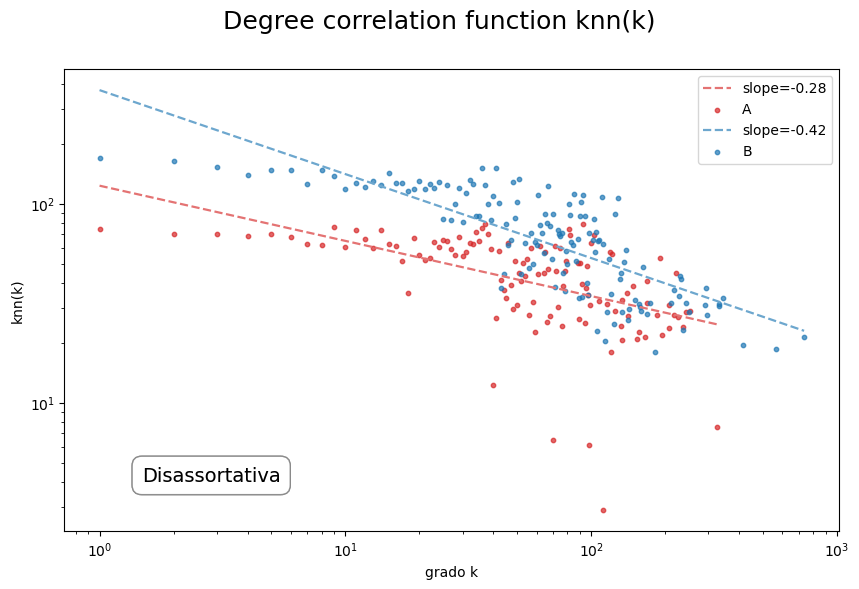

In [58]:
plot_knn([G_A, G_B], legend=['A','B'])

Osserviamo che la reti appaiono disassortative: mediamente i nodi di grado basso sono connessi a nodi di grado alto per entrambi i sottografi. In particolare possiamo evidenziare la presenza di due regimi:
- I nodi di grado < 10 si connettono mediamente a nodi di grado più alto, formando la perferia della rete;
- I nodi di grado > 10 seguono un andamento meno lineare, generando anche connessioni tra nodi coon grado simile, formando quindi un core.

Seppure in B possiamo notare che i nodi sono mediamente connessi a nodi di grado più alto rispetto ad A, gli andamenti della $knn$ risultano simili in entrambi i grafi.

# Studio della Polarizzazione


Finora abbiamo studiato la struttura topologica del grafo e delle sue comunità. Adesso concentreremo l'analisi sulle interconnessioni tra le comunità.

*La rete è ben divisa nelle due comunità? Rispetto ad un modello nullo quant'è la sua polarizzazione?*

Iniziamo valutando l'assortatività rispetto alle labels, così da capire se la rete presenta alta **omofilia**, cioè la tendenza dei nodi a connettersi a nodi appartenenti allo stesso gruppo.

In [6]:
group_label = [0 if v == 'A' else 1 for v in G.vs['group']] # creo una lista di 0->A, 1->B

In [ ]:
assortativita = G.assortativity_nominal(
    types=group_label,
    directed=False                
)
print(f"Assortatività nominale: {assortativita:.4f}")
if assortativita>0.7:
    print("-> Alta omofilia")

Assortatività nominale: 0.9327
-> Alta omofilia


Come ulteriore conferma della divisione in comunità della rete, mostriamo la mixing matrix
I coefficenti sulla diagonale della matrice sono la frazione dei link totali interni alle comunità, mentre i rimanenti sono le frazioni di link che le connettono tra loro.

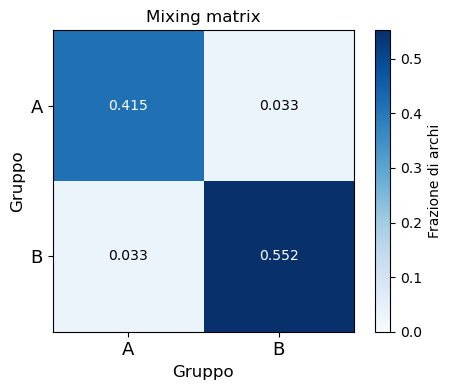

In [10]:
M, labels = mixing_matrix(G, partition=group_label, normalized=True)
plot_mixing_matrix(G, M, labels)

In [15]:
linkA = M[0, 0] + M[1, 0] 
linkB = M[1, 1] + M[1, 0] 
frazA = M[0, 0] / linkA # frazione dei link di A connessa internamente
frazB = M[1, 1] / linkB # frazione dei link di B connessa internamente

print(f"Frazione dei link di A sul totale {linkA:.2f}")
print(f"Frazione dei link di B sul totale {linkB:.2f}")
print(f"frazione dei link di A connessa internamente {frazA:.2f}")
print(f"frazione dei link di B connessa internamente {frazB:.2f}")

Frazione dei link di A sul totale 0.45
Frazione dei link di B sul totale 0.59
frazione dei link di A connessa internamente 0.93
frazione dei link di B connessa internamente 0.94


Dalla *mixing matrix* possiamo notare come solo il 3,3% dei nodi è identificabile come bridge tra A e B, che quindi formano due gruppi ben distinti.
Le frazioni di link delle comunità connessi internamente è simile, quindi non risulta una diversa propensione all'interazione con membri esterni.
Ne possiamo concludere che entrambe le fazioni siano sottoposte ad un fenomeno di **ecochambers**.

Per valutare se, come intuibile, la nostra divisione in comunità sia un fenomeno strutturale di polarizzazione e per quantificare l'effetto di dinamiche casuali, abbiamo confrontato la polarizzazione osservata nella nostra rete con la distribuzione generata da simulazioni random, che ne conservino la distribuzione di grado, come definito dal **Configuration Model**.
Abbiamo confrontato la frazione di link tra le comunità ottenute con le simulazioni con il valore $2pq$, dove $p$ e $q$ sono le frazioni di nodi appartenenti ad A e B. Il doppio del loro prodotto è il valore atteso della frazione di link tra le comunità in assenza di ulteriori vincoli. 
Abbiamo messo così in evidenza quanto il contributo casuale sia dovuto all'eterogeneità di grado osservata nella rete.

In [7]:
_, _, p, q, baseline = communities_statistics(G)
print(f"Probabilità p, che un nodo appartenga ad A {p*100:.2f}%")
print(f"Probabilità q, che un nodo appartenga ad B {q*100:.2f}%")
print(f"Valore atteso della frazione di link tra comunità A e B per modello random (ER) {baseline:.2f}")

Probabilità p, che un nodo appartenga ad A 55.49%
Probabilità q, che un nodo appartenga ad B 44.51%
Valore atteso della frazione di link tra comunità A e B per modello random (ER) 0.49


In [8]:
def test_configuration_model(G: ig.Graph, n_perm=2000, with_ei_index=True):

    group_label = np.array([1 if v == 'A' else 0 for v in G.vs['group']])
    results_simulated = np.zeros(n_perm)
    G_shuffled = G.copy()

    # configuration con metrica cross
    if not with_ei_index: 

        observed = cross_type_fraction(G, group_label)
        
        for i in range(n_perm):
            
            ig.Graph.rewire(G_shuffled, n=G_shuffled.ecount()*10)
            results_simulated[i]=cross_type_fraction(G_shuffled, group_label)
            barra_avanzamento(i, n_perm)


    # configuration con ei-index    
    else:
        
        observed = ei_index(G, group_label)
        
        for i in range(n_perm):
            
            ig.Graph.rewire(G_shuffled, n=G_shuffled.ecount()*10)
            results_simulated[i]=ei_index(G_shuffled, group_label)
            barra_avanzamento(i, n_perm)

            
    p_value = ( np.sum(results_simulated<=observed) + 1 ) / ( n_perm + 1 )   

    return observed, results_simulated, p_value

In [39]:
def plot_configuration_test(observed, results_simulated, baseline, bins=30):
    val_atteso = np.mean(results_simulated)
    fig, ax = plt.subplots(figsize=FIGSIZE)
    ax.axvline(observed, color=cmap(3), linestyle='--', label=f'observed={observed:.3f}')
    ax.axvline(baseline, color='black', linestyle='--', alpha=0.7, label=f'baseline={baseline:.2f}')

    n = ax.hist(results_simulated, bins=bins, color=cmap(0), density=True)
    ax.set_xlabel('cross-type edge fraction')
    ax.set_ylabel('density')
    ax.legend(frameon=True, bbox_to_anchor=(0.3,0.95), loc='upper left')
    fig.suptitle(f"Permutation test for cross-type edge fraction with rewire")


    axins = ax.inset_axes([0.3, 0.3, 0.4, 0.4])
   
    # Dati ingranditi nel riquadro
    axins.hist(results_simulated, bins=bins, color=cmap(0), edgecolor='white')
    axins.axvline(val_atteso, color=cmap(2), linestyle='--', label=f'mean={val_atteso:.2f}')
    axins.set_xlim(n[1].min(), n[1].max())  # Limiti della zona da zoomare
    axins.set_ylim(0, n[0].max()+1) # Limiti della zona da zoomare
    
    xticks = np.linspace(n[1].min().round(2), n[1].max().round(2),6)
    axins.set_xticks(xticks)
    axins.set_xticklabels(xticks)
    axins.legend()

    # Aggiunta automatica del rettangolo e delle linee di connessione
    ax.indicate_inset_zoom(axins, edgecolor='black', linestyle='--')

In [10]:
observed, results_simulated, p_value = test_configuration_model(G, n_perm=1000, with_ei_index=False)


[#############################-] 99% (999/1000)

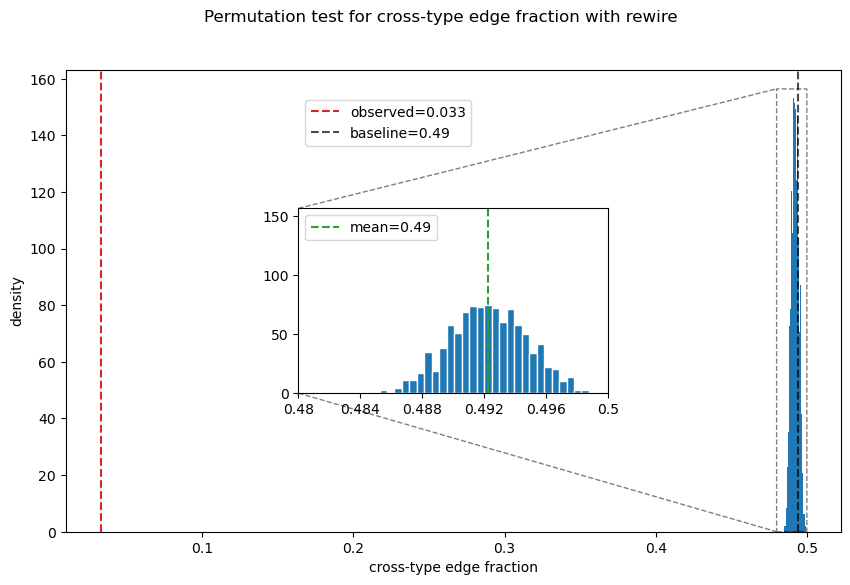

In [40]:
plot_configuration_test(observed, results_simulated, baseline)

Si osserva come il risultato ottenuto con il **Configuration Model** sia compatibile con quello puramente random e risulti in un contributo completamente trascurabile alla polarizzazione osservata.

In [43]:
k = 10
subgraph = subgraph_core(G, K_core = k, plot = False)
_, _, p_sub, q_sub, baseline_sub = communities_statistics(subgraph)


Un risultato più interessante può essere ottenuto restringendoci ad una sottorete formata dai nodi più centrali, ottenuta selezionando i nodi appartenenti al k-core = 10.
Per concentrarci sulla dinamica tra i core delle comunità.

In [ ]:
observed_sub, results_simulated_sub, _ = test_configuration_model(subgraph, n_perm=1000, with_ei_index=False)

[##----------------------------] 9% (96/1000)

In [ ]:
plot_configuration_test(observed_sub, results_simulated_sub, baseline_sub)

NameError: name 'observed_sub' is not defined

Per i core della rete si può osservare l'emergere di polarizzazione anche solo considerando dimìnamiche random e questo fenomeno risulta essere maggiormente amplificato dalla distribuzione di grado, poichè stiamo analizzando un sottoinsieme degli hub della rete. Anche in questo il contributo random è trascurabile rispetto alla polarizzazione osservata.

# Conclusioni

Analizzando le comunità abbiamo potuto verificare le seguenti considerazioni:
- Entrambe le comunità A e B presentano una struttura a echo chambers, con una parte centrale con nodi più connessi tra loro e una periferia legata preferenzialmente agli hub delle reti. Le reti sono infatti entrambe disassortative nel grado.
- La comunità A, che corrisponde all'orientamento politico di sinistra presenta una struttura con più nodi periferici, mediamente più distanti dal core. Questo sottolinea un fenomeno accentrativo più effeciente nella destra riguardo il tema dell'immigrazione. Quest'ultimo è infatti un tema molto più caro alla destra soprattutto in vista delle elezioni in cui il governo uscente era di sinistra. Infatti nel 2019 la comunità di destra era molto meno numerosa rispetto al 2023 (Capitolo 1).
- La rete presenta alta omofilia per appartenenza ai gruppi politici. La polarizzazione della rete è molto alta e dipende in modon trascurabile da fenomeni random.


